In [5]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

url = "https://overpass-api.de/api/interpreter"
cities = ["Ahmedabad", "Surat", "Vadodara"]
all_data = [] 

for city in cities:
    
    query = f"""
    [out:json];
    area["name"="{city}"]->.searchArea;
    (
      node["highway"="traffic_signals"](area.searchArea);
    );
    out body;
    """
    
    response = requests.post(url, data=query)
    data = response.json()

    for element in data["elements"]:
        element["city"]=city
        all_data.append(element)
    
    df = pd.DataFrame(all_data)
    
   
 
    df.to_csv("Gujarat_traffic_signals.csv", index=False)
    
    print("All citys CSV saved successfully ✅")

All citys CSV saved successfully ✅
All citys CSV saved successfully ✅
All citys CSV saved successfully ✅


In [6]:
city_count=df["city"].value_counts()
city_count

city
Ahmedabad    66
Vadodara      5
Surat         1
Name: count, dtype: int64

In [7]:
max_city = city_count.idxmax()
max_count = city_count.max()
print("City with Maximum Signals:", max_city, max_count)


City with Maximum Signals: Ahmedabad 66


In [8]:
total_signals = len(df)
print("Total Signals:", total_signals)

Total Signals: 72


In [9]:
average_signals = city_count.mean()
print("Average Signals per City:", round(average_signals,2))

Average Signals per City: 24.0


In [10]:
# Difference Ahmedabad vs Surat

difference=abs(city_count.get("Ahmedabad",0)-city_count.get("Surat",0))
print("Ahmedabad vs Surat Difference:", difference)


Ahmedabad vs Surat Difference: 65


In [12]:
df["lat_range"] = pd.cut(df["lat"], bins=5)
lat_distribution = df["lat_range"].value_counts().sort_index()
print("Latitude Range Distribution:")
print(lat_distribution)

Latitude Range Distribution:
lat_range
(21.199, 21.571]     1
(21.571, 21.941]     0
(21.941, 22.312]     5
(22.312, 22.682]     0
(22.682, 23.053]    66
Name: count, dtype: int64


In [13]:
df["lon_range"] = pd.cut(df["lon"], bins=5)
lon_distribution = df["lon_range"].value_counts().sort_index()
print("Longitude Distribution:")
print(lon_distribution)

Longitude Distribution:
lon_range
(72.529, 72.664]    66
(72.664, 72.798]     1
(72.798, 72.933]     0
(72.933, 73.067]     0
(73.067, 73.201]     5
Name: count, dtype: int64


In [17]:
max_north_signal = df.loc[df["lat"].idxmax()]

print("Maximum Northern Signal:")
print(max_north_signal[["city","lat","lon"]])

Maximum Northern Signal:
city    Ahmedabad
lat     23.052703
lon     72.610318
Name: 65, dtype: object


In [19]:
city_count= df["city"].value_counts()
top3 = city_count.head(3)
print("Top 3 Cities by Signal Count:")
print(top3)

Top 3 Cities by Signal Count:
city
Ahmedabad    66
Vadodara      5
Surat         1
Name: count, dtype: int64


In [21]:
total_signals = len(df)
percentage_df = city_count.reset_index()
percentage_df.columns = ["city", "signal_count"]
percentage_df["percentage_share"] = (
    percentage_df["signal_count"] / total_signals
) * 100

print("Percentage Share of Each City:")
print(percentage_df)

Percentage Share of Each City:
        city  signal_count  percentage_share
0  Ahmedabad            66         91.666667
1   Vadodara             5          6.944444
2      Surat             1          1.388889


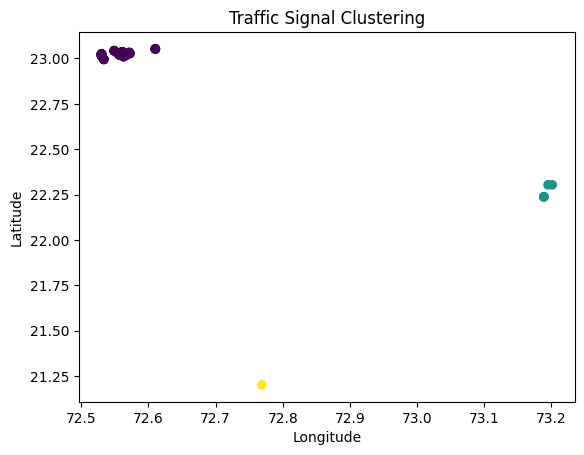

In [38]:
X=df[["lat","lon"]]

kmeans=KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(X)
plt.figure()
plt.scatter(df["lon"], df["lat"], c=df["cluster"])
plt.title("Traffic Signal Clustering")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [39]:
df["lat_bin"] = pd.cut(df["lat"], bins=5)
df["lon_bin"] = pd.cut(df["lon"], bins=5)

density = df.groupby(["lat_bin","lon_bin"]).size().reset_index(name="count")

print("High Density Zones:")
print(density.sort_values("count", ascending=False).head())

High Density Zones:
             lat_bin           lon_bin  count
20  (22.682, 23.053]  (72.529, 72.664]     66
14  (21.941, 22.312]  (73.067, 73.201]      5
1   (21.199, 21.571]  (72.664, 72.798]      1
0   (21.199, 21.571]  (72.529, 72.664]      0
2   (21.199, 21.571]  (72.798, 72.933]      0


C:\Users\saksh\AppData\Local\Temp\ipykernel_4044\3971474936.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  density = df.groupby(["lat_bin","lon_bin"]).size().reset_index(name="count")


In [41]:
max_val = city_count.max()
smart_index = (city_count / max_val) * 100

print("Smart City Readiness Index:")
print(smart_index)

Smart City Readiness Index:
city
Ahmedabad    100.000000
Vadodara       7.575758
Surat          1.515152
Name: count, dtype: float64


In [42]:
target = city_count.mean() * 1.2

need_more = city_count[city_count < target]

print("Cities That May Need More Signals:")
print(need_more)

Cities That May Need More Signals:
city
Vadodara    5
Surat       1
Name: count, dtype: int64


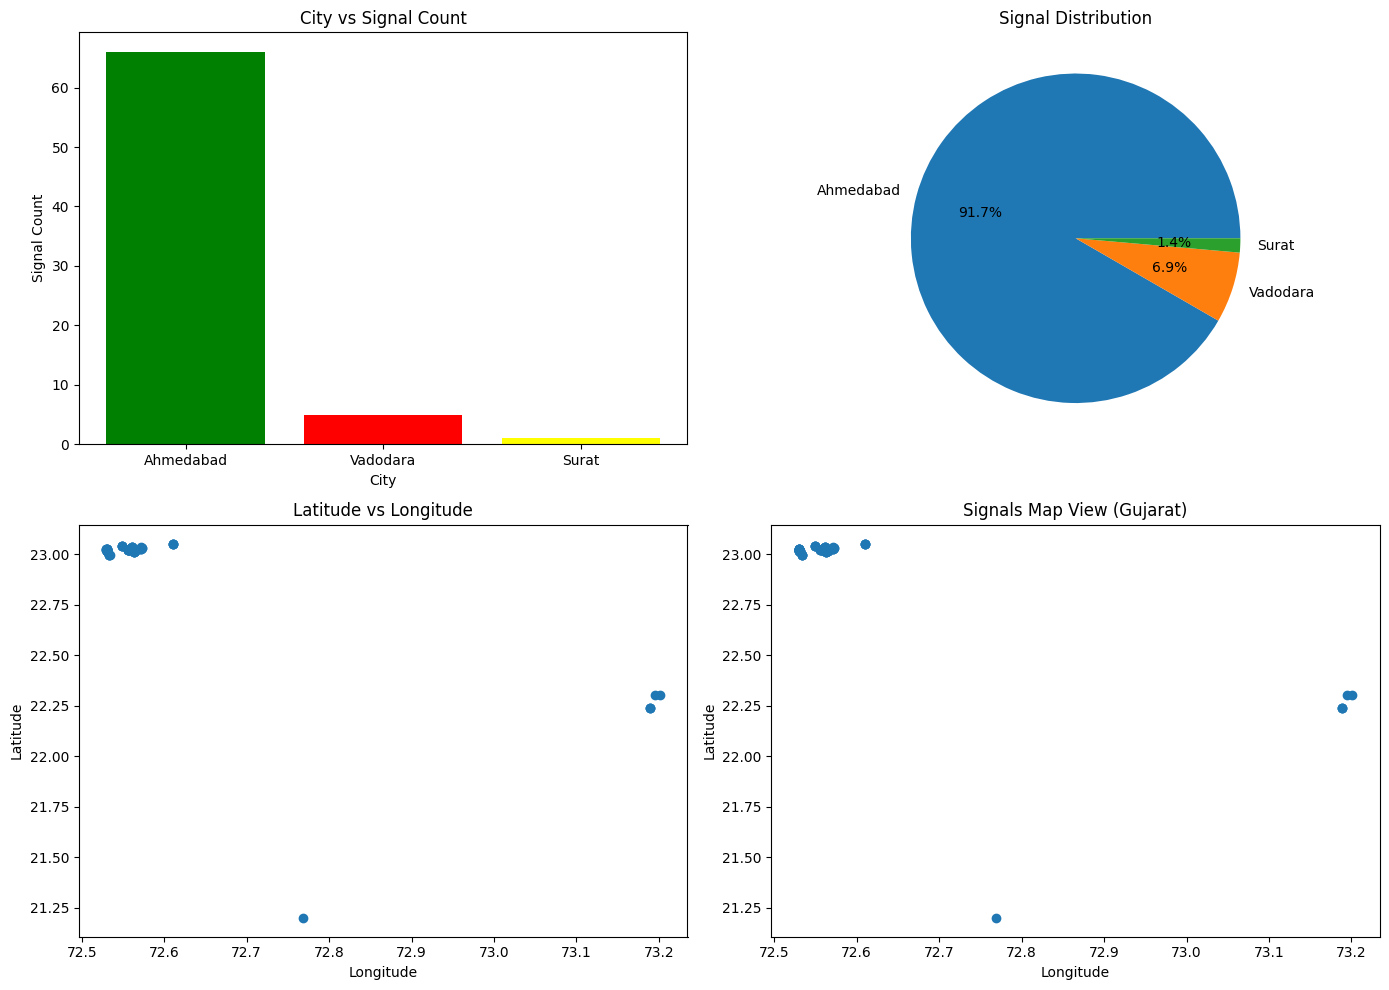

In [43]:
plt.figure(figsize=(14,10))

colors=["green","red","yellow"]

plt.subplot(2,2,1)
plt.bar(city_count.index,city_count.values,color=colors)
plt.title("City vs Signal Count")
plt.xlabel("City")
plt.ylabel("Signal Count")

plt.subplot(2,2,2)
plt.pie(city_count.values, labels=city_count.index, autopct="%1.1f%%")
plt.title("Signal Distribution")


plt.subplot(2,2,3)
plt.scatter(df["lon"], df["lat"])
plt.title("Latitude vs Longitude")
plt.xlabel("Longitude")
plt.ylabel("Latitude")


plt.subplot(2,2,4)
plt.scatter(df["lon"], df["lat"])
plt.title("Signals Map View (Gujarat)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()